In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("spotify.csv")

df.head()

Matplotlib is building the font cache; this may take a moment.


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Spotify Data Analysis 

## Data Cleaning & Visualization Project

### Objective
To analyze Spotify track data using Python and perform:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Insight Generation

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
df.shape

(114000, 22)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

In [4]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [5]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.shape

(114000, 20)

In [7]:
df.duplicated().sum()

np.int64(450)

In [8]:
df.drop_duplicates(inplace=True)
df.shape

(113550, 20)

In [9]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

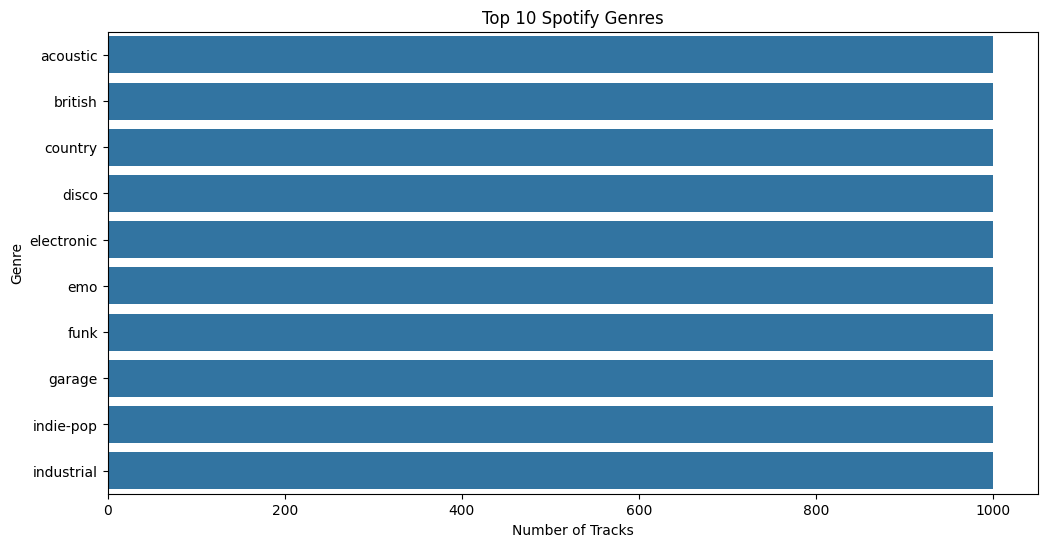

In [10]:
top_genres = df['track_genre'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Spotify Genres")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.show()

### Insight

The graph shows the top 10 most common Spotify genres in the dataset. Certain genres appear significantly more frequently than others, indicating dominant music trends and listener preferences on Spotify.

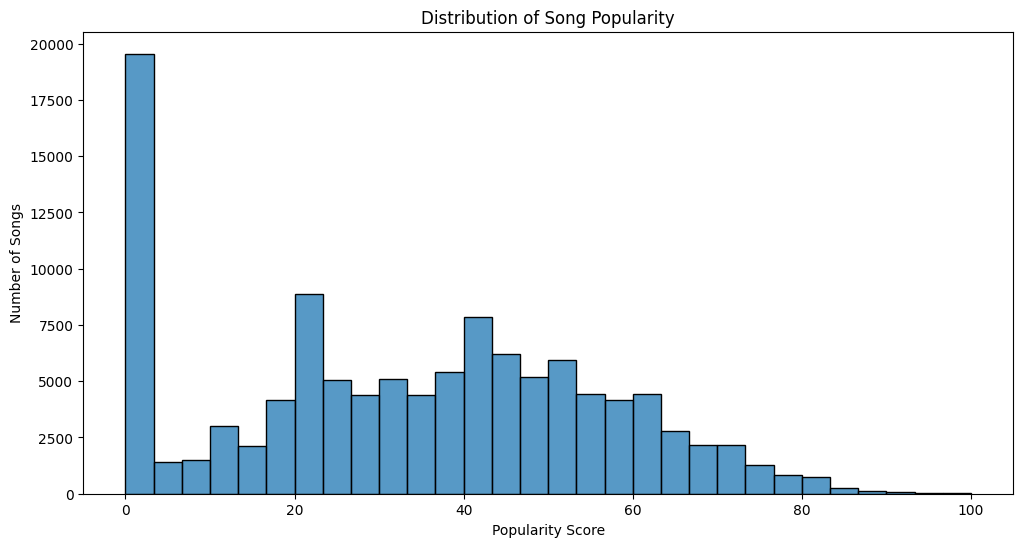

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(df['popularity'], bins=30)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")

plt.show()

### Insight

The popularity distribution graph shows that most Spotify tracks fall within the medium popularity range, while only a smaller number of songs achieve extremely high popularity scores.

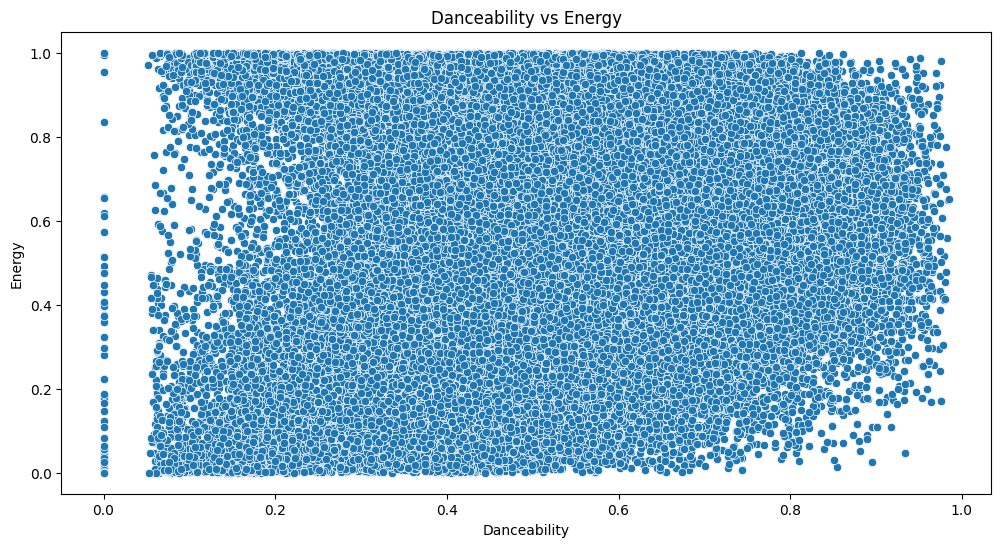

In [12]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='danceability',
    y='energy',
    data=df
)

plt.title("Danceability vs Energy")
plt.xlabel("Danceability")
plt.ylabel("Energy")

plt.show()

### Insight

The scatter plot shows a positive relationship between danceability and energy. Songs with higher energy levels often tend to be more danceable, although there are some exceptions.

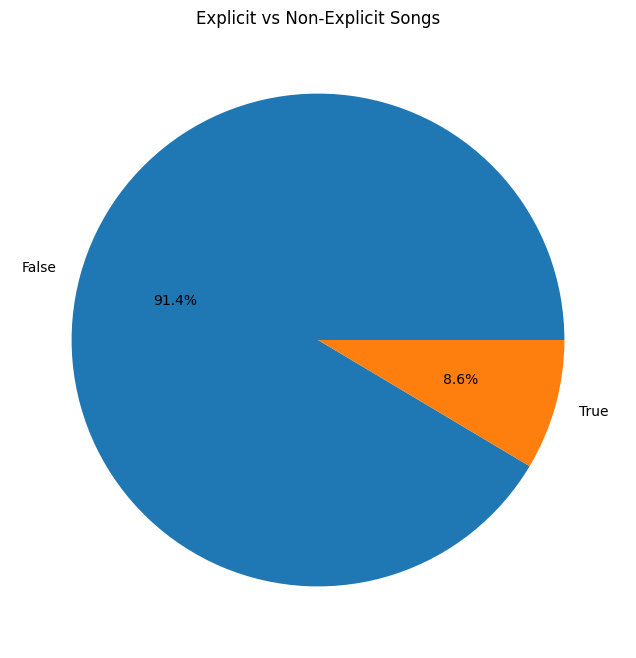

In [13]:
explicit_counts = df['explicit'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    explicit_counts,
    labels=explicit_counts.index,
    autopct='%1.1f%%'
)

plt.title("Explicit vs Non-Explicit Songs")

plt.show()

### Insight

The pie chart shows that non-explicit songs form the majority of tracks in the Spotify dataset, while explicit songs represent a smaller portion of the overall music collection.

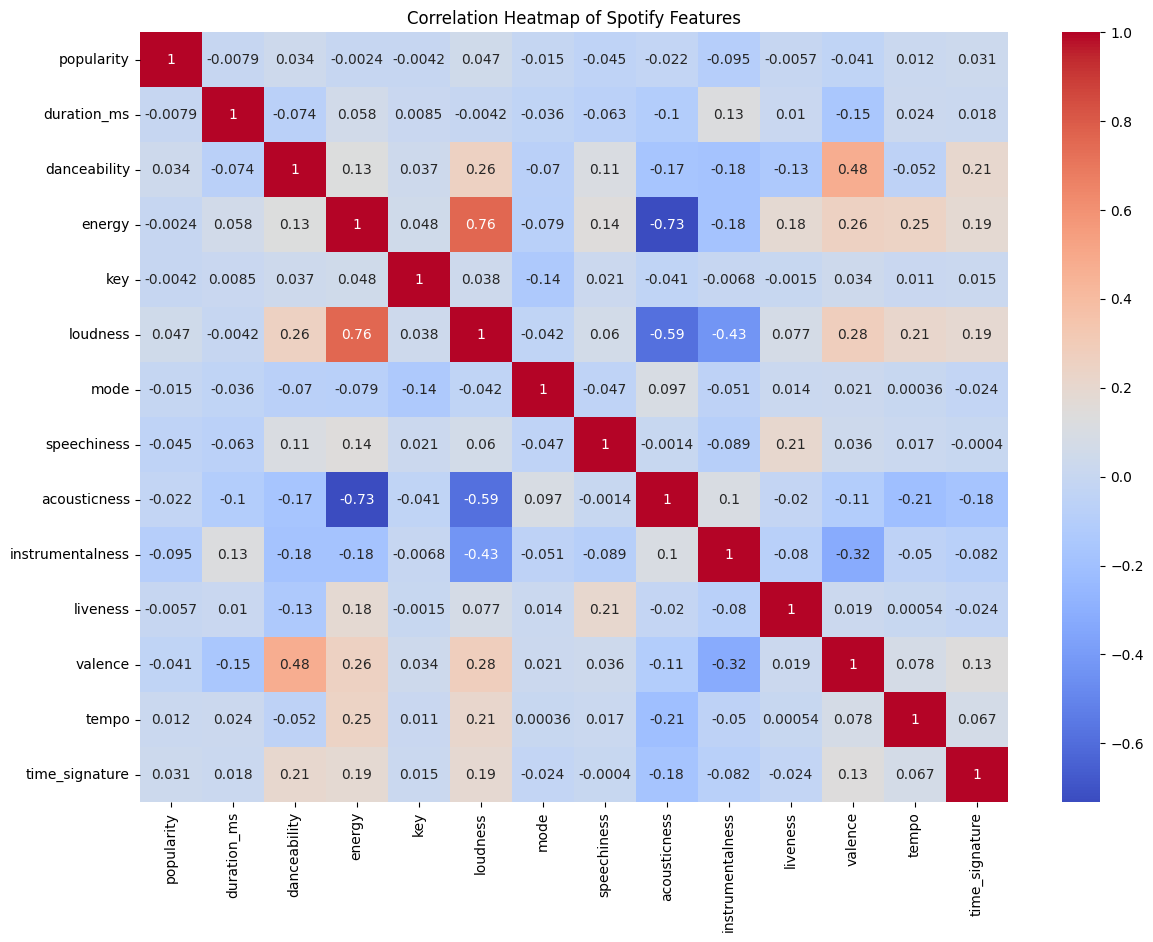

In [14]:
plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Spotify Features")

plt.show()

### Insight

The heatmap highlights relationships between numerical audio features. Certain attributes such as energy and loudness show strong positive correlations, while acousticness tends to have negative correlations with energy-related features.

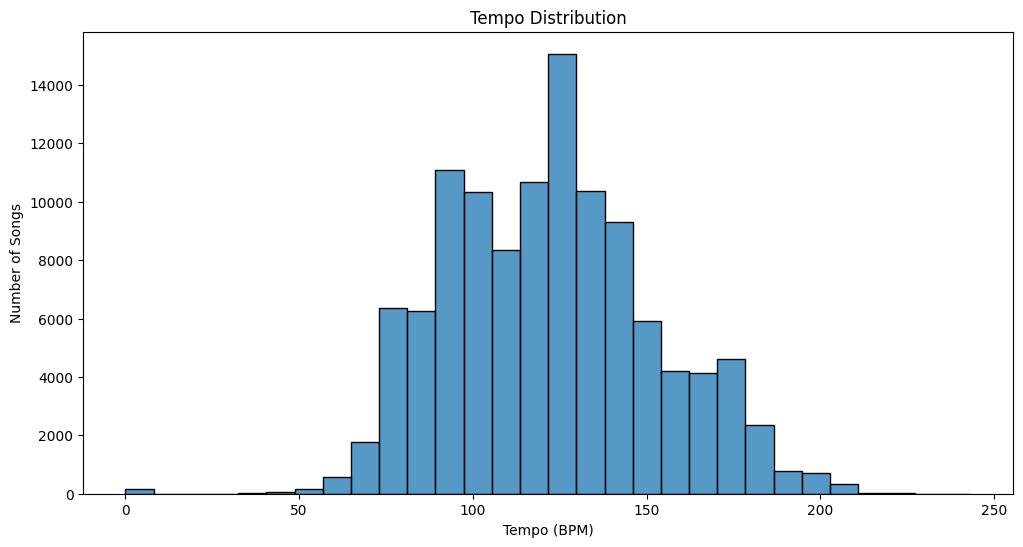

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(df['tempo'], bins=30)

plt.title("Tempo Distribution")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Number of Songs")

plt.show()

### Insight

Most songs are concentrated within a moderate tempo range, indicating that Spotify tracks generally follow commonly preferred BPM patterns suitable for mainstream listening.

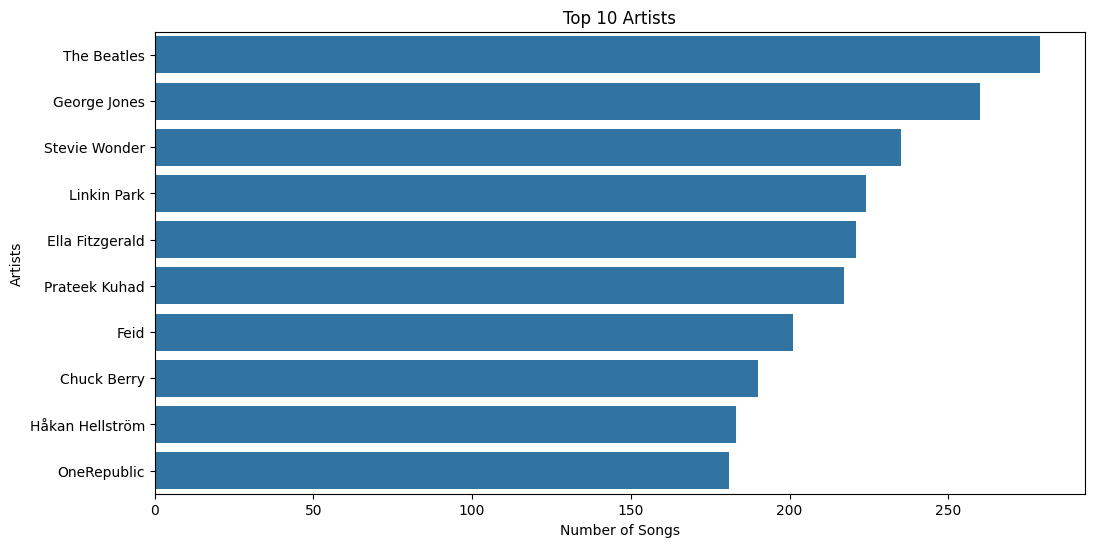

In [16]:
top_artists = df['artists'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 10 Artists")
plt.xlabel("Number of Songs")
plt.ylabel("Artists")

plt.show()

### Insight

The graph shows the artists with the highest number of tracks in the dataset. Some artists appear significantly more frequently, reflecting their strong presence across Spotify genres and playlists.

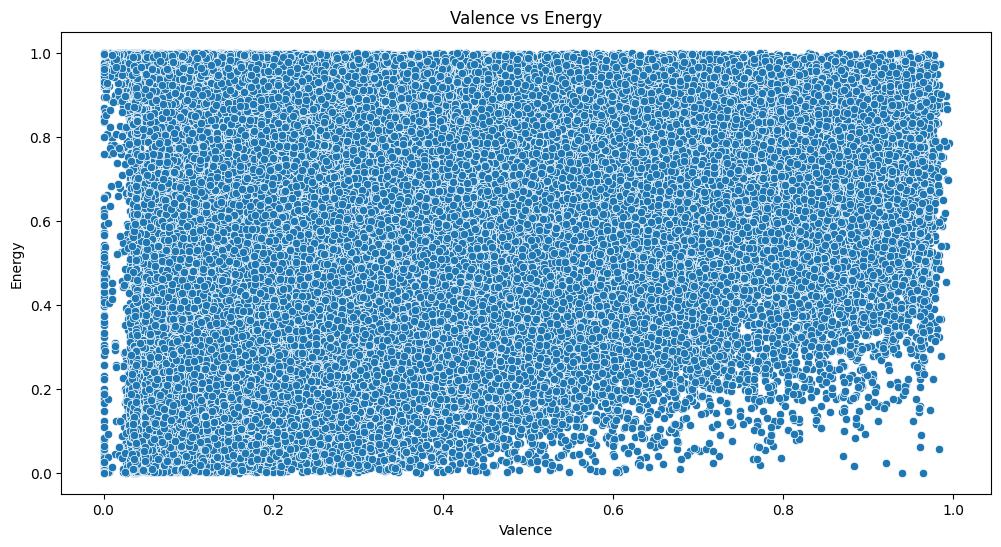

In [17]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='valence',
    y='energy',
    data=df
)

plt.title("Valence vs Energy")
plt.xlabel("Valence")
plt.ylabel("Energy")

plt.show()

### Insight

The graph indicates that songs with higher energy levels often tend to have more positive emotional tones (higher valence), although emotional mood varies across different energy levels.

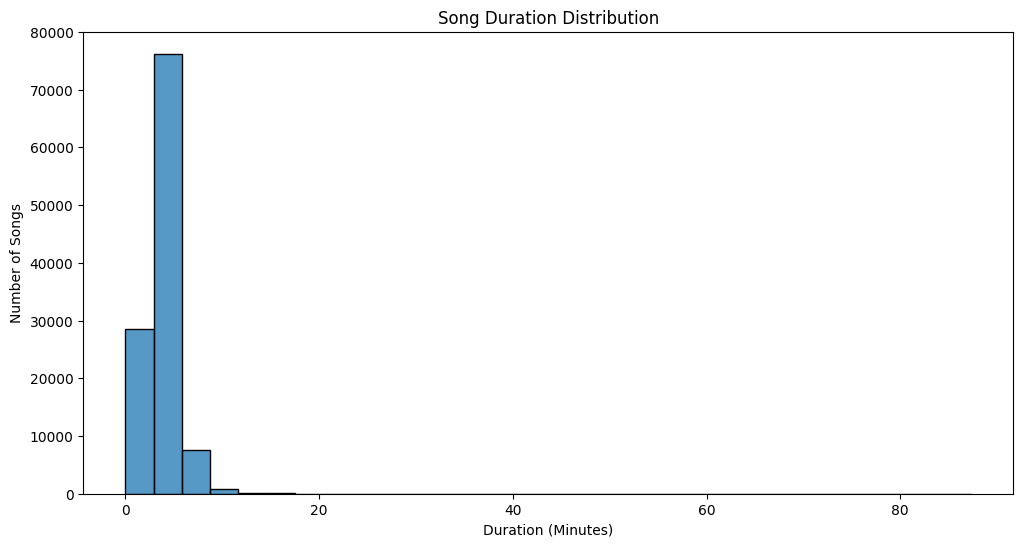

In [18]:
plt.figure(figsize=(12,6))

sns.histplot(df['duration_ms'] / 60000, bins=30)

plt.title("Song Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")

plt.show()

### Insight

Most Spotify songs fall within a standard duration range of around 2 to 5 minutes, showing the common structure followed in modern music production.

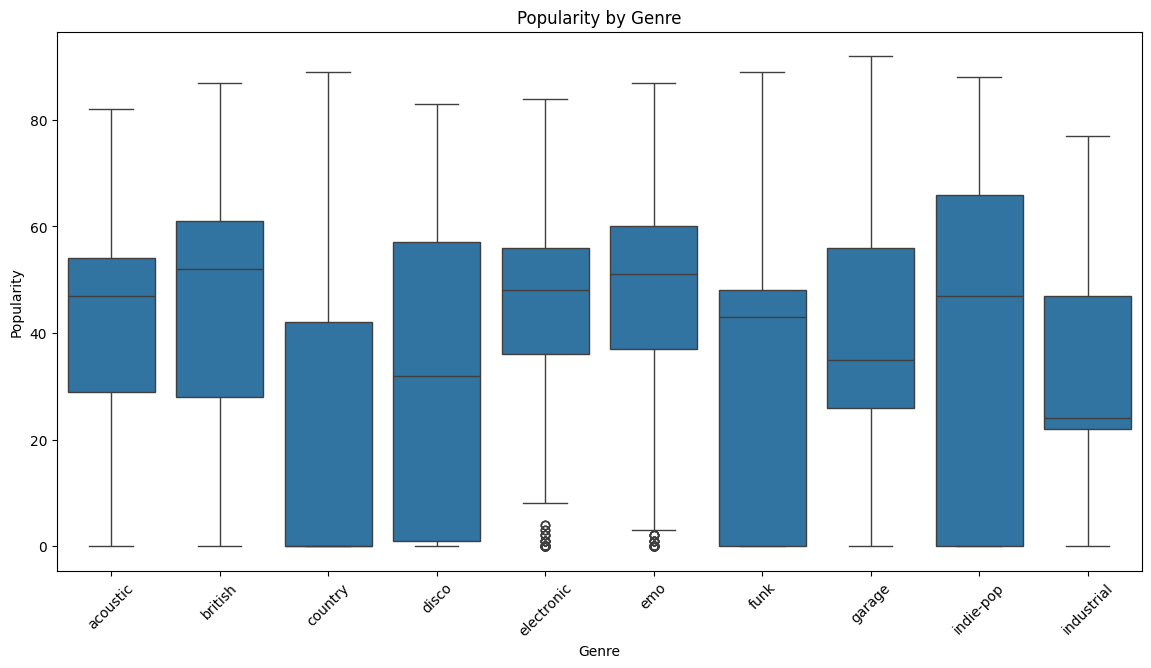

In [19]:
top10_genres = df['track_genre'].value_counts().head(10).index

filtered_df = df[df['track_genre'].isin(top10_genres)]

plt.figure(figsize=(14,7))

sns.boxplot(
    x='track_genre',
    y='popularity',
    data=filtered_df
)

plt.title("Popularity by Genre")
plt.xlabel("Genre")
plt.ylabel("Popularity")

plt.xticks(rotation=45)

plt.show()

### Insight

The boxplot compares popularity scores across major genres. Some genres consistently achieve higher popularity ranges, while others show wider variation in listener engagement.

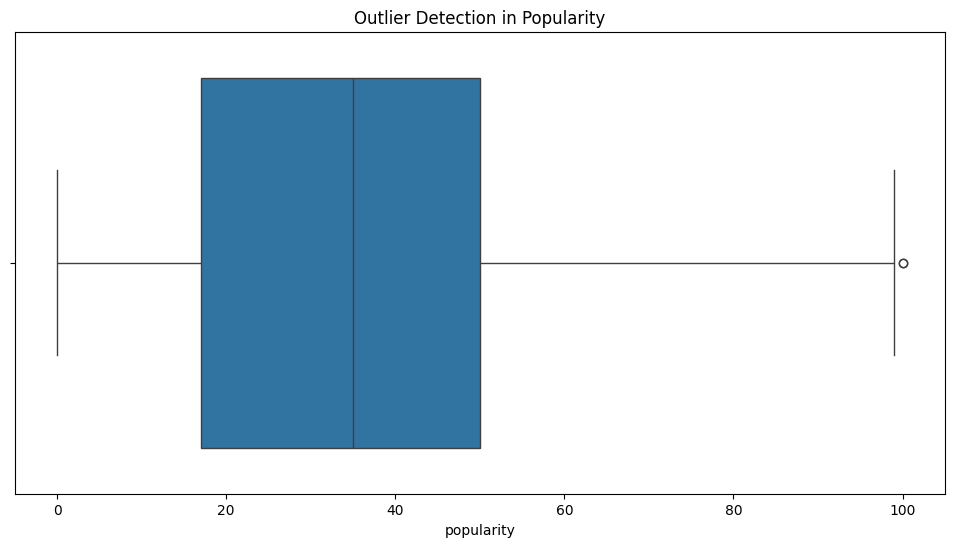

In [20]:
plt.figure(figsize=(12,6))

sns.boxplot(x=df['popularity'])

plt.title("Outlier Detection in Popularity")

plt.show()

### Insight

The boxplot helps identify outliers in song popularity. A small number of tracks have extremely high popularity scores compared to the majority of songs in the dataset.

# Final Insights

1. Certain Spotify genres dominate the dataset, indicating strong listener preference toward specific music categories.

2. Most songs fall within the medium popularity range, while only a limited number achieve extremely high popularity.

3. Danceability and energy show a positive relationship, suggesting energetic songs are often more suitable for dancing.

4. Non-explicit songs form the majority of tracks available in the dataset.

5. Audio features such as energy and loudness are strongly correlated, while acousticness often shows negative correlation with energetic tracks.

6. Most Spotify tracks follow a standard song duration pattern of approximately 2 to 5 minutes.

7. Tempo analysis shows that songs are generally concentrated within commonly preferred BPM ranges.

8. Some genres consistently achieve higher popularity scores compared to others.

9. Emotional positivity (valence) tends to increase with higher song energy levels.

10. Certain artists appear more frequently in the dataset, reflecting their broader presence across genres and playlists.

# Conclusion

This project focused on cleaning, analyzing, and visualizing Spotify track data using Python libraries such as Pandas, Matplotlib, and Seaborn.

The dataset was successfully preprocessed by handling missing values, removing duplicates, and cleaning unnecessary columns. Multiple visualizations were created to understand genre trends, popularity distribution, artist frequency, audio feature relationships, and song characteristics.

The analysis provided meaningful insights into Spotify music trends and demonstrated how data visualization can support storytelling and decision-making in music analytics.

Overall, this project improved understanding of:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Insight Generation using Python